# Google Ads Campaign Simulation & Performance Optimization

In this project, we explore a dataset simulating marketing campaign performance across various channels including social, search, media, and influencer campaigns. Using key performance metrics such as impressions, clicks, spend, conversions, and revenue, we calculate and visualize the effectiveness of each campaign.

The goal is to:
- Simulate a Google Ads style analysis
- Identify high and low performing campaigns
- Calculate KPIs like CTR, CPC, Conversion Rate, and ROAS
- Recommend optimization strategies for better ad spend efficiency

This type of analysis is critical for marketing professionals aiming to maximize the return on advertising investment (ROAS) and improve digital performance.


# Section 1 - Load and Preview Data
We begin by loading the marketing dataset, which includes information on campaign performance such as impressions, clicks, spend, leads, orders, and revenue. This gives us a foundation for calculating meaningful advertising KPIs.

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [35]:
df = pd.read_csv('Marketing.csv')
df.head()



,id,c_date,campaign_name,category,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
0,1,2021-02-01,facebook_tier1,social,349043,148263,7307.37,1210,13,1,4981.0
1,2,2021-02-01,facebOOK_tier2,social,348934,220688,16300.20,1640,48,3,14962.0
2,3,2021-02-01,google_hot,search,89459845,22850,5221.60,457,9,1,7981.0
3,4,2021-02-01,google_wide,search,127823,147038,6037.00,1196,24,1,2114.0
4,5,2021-02-01,youtube_blogger,influencer,10934,225800,29962.20,2258,49,10,84490.0


In [ ]:
# Basic Analysis
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (308, 11)

Column Names:
 Index(['id', 'c_date', 'campaign_name', 'category', 'campaign_id',
       'impressions', 'mark_spent', 'clicks', 'leads', 'orders', 'revenue'],
      dtype='object')

Missing Values:
 id               0
c_date           0
campaign_name    0
category         0
campaign_id      0
impressions      0
mark_spent       0
clicks           0
leads            0
orders           0
revenue          0
dtype: int64


### Data Overview
The dataset contains daily campaign performance across multiple marketing channels including social, search, and influencer campaigns. Each row represents campaign-level performance for a given date, including:

- Impressions
- Clicks
- Marketing Spend
- Leads
- Orders
- Revenue

This structure enables calculation of performance KPIs and campaign-level aggregation.

## Section 2 - Calculating Key Performance indicators

In this step, we calculate important Google Ads KPIs including Click-Through Rate (CTR), Cost Per Click (CPC), Cost Per Lead, Conversion Rate, Return on Ad Spend (ROAS), Cost Per Action(CPA) and Profit . These help us measure the efficiency and profitability of each campaign.

In [64]:
#calculate KPIs
df['CTR'] = np.where(df['impressions'] > 0,
                     df['clicks'] / df['impressions'],
                     np.nan)

df['CPC'] = np.where(df['clicks'] > 0,
                     df['mark_spent'] / df['clicks'],
                     np.nan)

df['Cost_per_Lead'] = np.where(df['leads'] > 0,
                               df['mark_spent'] / df['leads'],
                               np.nan)

df['Conversion_Rate'] = np.where(df['clicks'] > 0,
                                 df['orders'] / df['clicks'],
                                 np.nan)

df['ROAS'] = np.where(df['mark_spent'] > 0,
                      df['revenue'] / df['mark_spent'],
                      np.nan)

df['CPA'] = np.where(df['orders'] > 0,
                     df['mark_spent'] / df['orders'],
                     np.nan)

df['Profit'] = df['revenue'] - df['mark_spent']

kpi_cols = ['CTR','CPC','Cost_per_Lead','Conversion_Rate','ROAS','CPA','Profit']
df[kpi_cols] = df[kpi_cols].round(3)

df.head()



,id,c_date,campaign_name,category,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue,CTR,CPC,Cost_per_Lead,Conversion_Rate,ROAS,CPA,Profit
0,1,2021-02-01,facebook_tier1,social,349043,148263,7307.37,1210,13.0,1.0,4981.0,0.008,6.039,562.105,0.001,0.682,7307.37,-2326.37
1,2,2021-02-01,facebOOK_tier2,social,348934,220688,16300.20,1640,48.0,3.0,14962.0,0.007,9.939,339.588,0.002,0.918,5433.40,-1338.20
2,3,2021-02-01,google_hot,search,89459845,22850,5221.60,457,9.0,1.0,7981.0,0.020,11.426,580.178,0.002,1.528,5221.60,2759.40
3,4,2021-02-01,google_wide,search,127823,147038,6037.00,1196,24.0,1.0,2114.0,0.008,5.048,251.542,0.001,0.350,6037.00,-3923.00
4,5,2021-02-01,youtube_blogger,influencer,10934,225800,29962.20,2258,49.0,10.0,84490.0,0.010,13.269,611.473,0.004,2.820,2996.22,54527.80


## Section 3 - Summarizing Campaign-Level Performance
To evaluate performance at a strategic level, we aggregate results by campaign and recompute weighted KPIs from total impressions, clicks, spend, and revenue. This ensures metrics such as CTR, CPC, Conversion Rate, and ROAS reflect true campaign-level performance rather than simple averages of daily values.

In [63]:
campaign_summary = df.groupby('campaign_name').agg({
    'impressions': 'sum',
    'clicks': 'sum',
    'mark_spent': 'sum',
    'leads': 'sum',
    'orders': 'sum',
    'revenue': 'sum'
}).reset_index()

# Recalculate KPIs for the group
campaign_summary['CTR'] = np.where(campaign_summary['impressions'] > 0,
                                  campaign_summary['clicks'] / campaign_summary['impressions'],
                                  np.nan)

campaign_summary['CPC'] = np.where(campaign_summary['clicks'] > 0,
                                  campaign_summary['mark_spent'] / campaign_summary['clicks'],
                                  np.nan)

campaign_summary['Cost_per_Lead'] = np.where(campaign_summary['leads'] > 0,
                                            campaign_summary['mark_spent'] / campaign_summary['leads'],
                                            np.nan)

campaign_summary['Conversion_Rate'] = np.where(campaign_summary['clicks'] > 0,
                                              campaign_summary['orders'] / campaign_summary['clicks'],
                                              np.nan)

campaign_summary['ROAS'] = np.where(campaign_summary['mark_spent'] > 0,
                                   campaign_summary['revenue'] / campaign_summary['mark_spent'],
                                   np.nan)

campaign_summary['CPA'] = np.where(campaign_summary['orders'] > 0,
                                  campaign_summary['mark_spent'] / campaign_summary['orders'],
                                  np.nan)

campaign_summary['Profit'] = campaign_summary['revenue'] - campaign_summary['mark_spent']
ratio_cols = ['CTR','Conversion_Rate','ROAS']
money_cols = ['CPC','Cost_per_Lead','CPA','Profit']

campaign_summary[ratio_cols] = campaign_summary[ratio_cols].round(4)
campaign_summary[money_cols] = campaign_summary[money_cols].round(2)
campaign_summary = campaign_summary.sort_values('ROAS', ascending=False)
campaign_summary

,campaign_name,impressions,clicks,mark_spent,leads,orders,revenue,CTR,CPC,Cost_per_Lead,Conversion_Rate,ROAS,CPA,Profit
10,youtube_blogger,43688313,450014,4057936.51,9931.0,1914.0,15311433.0,0.0103,9.02,408.61,0.0043,3.7732,2120.13,11253496.49
3,facebook_retargeting,976685,29954,266466.22,506.0,108.0,536919.0,0.0307,8.90,526.61,0.0036,2.0150,2467.28,270452.78
5,google_hot,4628993,90048,1199998.76,1833.0,281.0,2205747.0,0.0195,13.33,654.66,0.0031,1.8381,4270.46,1005748.24
8,instagram_tier1,75136799,269961,2565277.25,6632.0,758.0,4544124.0,0.0036,9.50,386.80,0.0028,1.7714,3384.27,1978846.75
7,instagram_blogger,34112411,299959,4247367.57,7008.0,1100.0,5808454.0,0.0088,14.16,606.07,0.0037,1.3675,3861.24,1561086.43
0,banner_partner,1068337427,420003,5026674.76,10149.0,1566.0,6152960.0,0.0004,11.97,495.29,0.0037,1.2241,3209.88,1126285.24
4,facebook_tier1,63044882,239997,2564793.48,3535.0,474.0,2396412.0,0.0038,10.69,725.54,0.0020,0.9343,5410.96,-168381.48
1,facebOOK_tier2,69623161,329973,4693870.97,8428.0,688.0,3463306.0,0.0047,14.23,556.94,0.0021,0.7378,6822.49,-1230564.97
6,google_wide,67669259,240006,2260401.31,5274.0,547.0,1499318.0,0.0035,9.42,428.59,0.0023,0.6633,4132.36,-761083.31
9,instagram_tier2,137806768,509992,1066153.75,10374.0,313.0,670460.0,0.0037,2.09,102.77,0.0006,0.6289,3406.24,-395693.75


## Section 4 - Visualizing Top Campaigns by ROAS and CTR

We use bar charts to highlight the best and worst performing campaigns based on key metrics like ROAS and CTR. These visuals help quickly identify which campaigns are driving the most value and which ones may require closer scrutiny.

/var/folders/8p/4rz_901s195bwprm6fpjf6xm0000gn/T/ipykernel_55897/1262242256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=campaign_summary.sort_values('ROAS', ascending=False), x='ROAS', y='campaign_name', palette='crest')


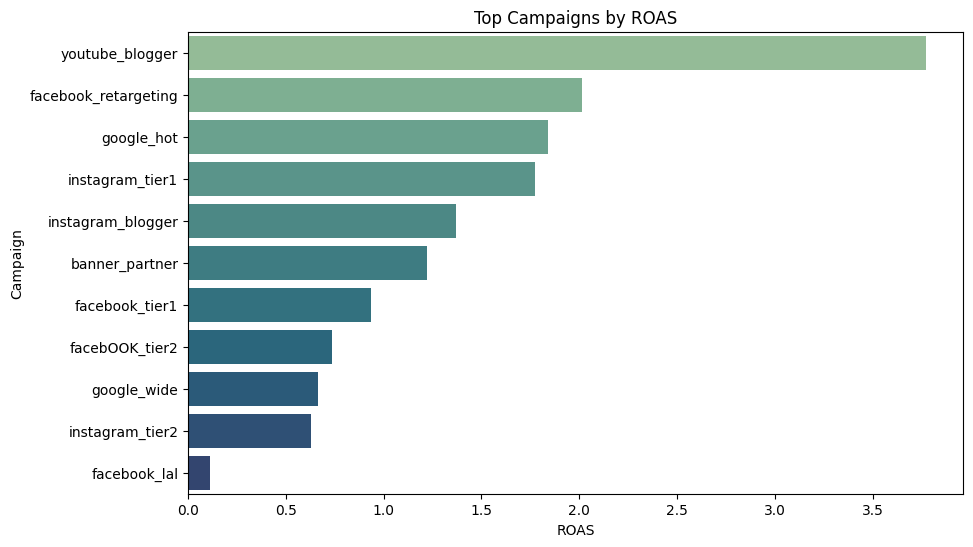

In [60]:
campaign_summary['CTR_pct'] = campaign_summary['CTR'] * 100
plt.figure(figsize=(10, 6))
sns.barplot(data=campaign_summary.sort_values('ROAS', ascending=False), x='ROAS', y='campaign_name', palette='crest')
plt.title('Top Campaigns by ROAS')
plt.xlabel('ROAS')
plt.ylabel('Campaign')
plt.show()

/var/folders/8p/4rz_901s195bwprm6fpjf6xm0000gn/T/ipykernel_55897/2113691318.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=campaign_summary.sort_values('CTR_pct', ascending=False), x='CTR_pct', y='campaign_name', palette='flare')


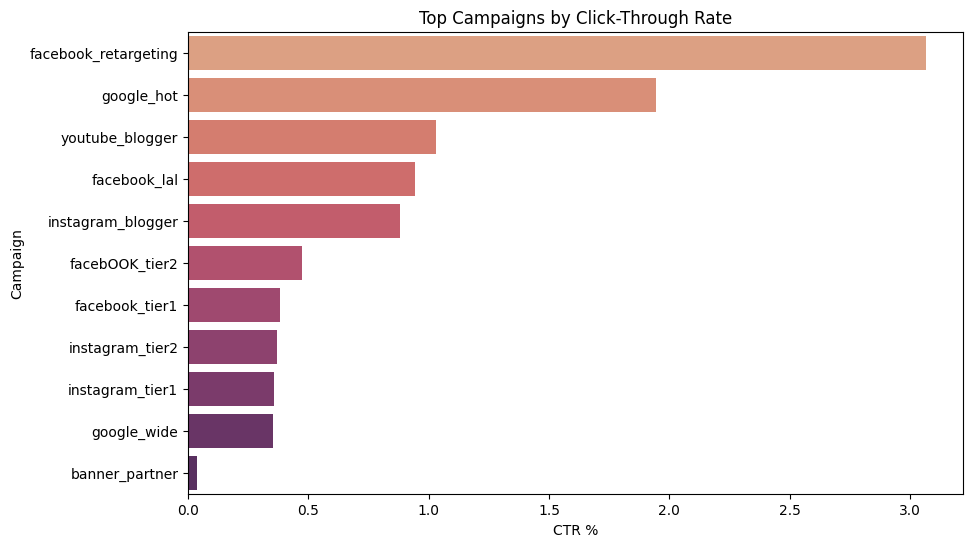

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(data=campaign_summary.sort_values('CTR_pct', ascending=False), x='CTR_pct', y='campaign_name', palette='flare')
plt.title('Top Campaigns by Click-Through Rate')
plt.xlabel('CTR %')
plt.ylabel('Campaign')
plt.show()

## Section 5 - Performance Classifacation 

We classify campaigns into performance tiers using both profitability (ROAS) and engagement efficiency (CTR). Campaigns below breakeven (ROAS < 1) are flagged for budget review, while top quartile performers are identified for potential scaling.

In [59]:
# Quantile thresholds (top/bottom quartiles)
roas_75 = campaign_summary['ROAS'].quantile(0.75)
roas_25 = campaign_summary['ROAS'].quantile(0.25)
ctr_75  = campaign_summary['CTR'].quantile(0.75)
ctr_25  = campaign_summary['CTR'].quantile(0.25)

def performance_tag(row):
    # 1) Profitability gate (most important)
    if pd.isna(row['ROAS']):
        return 'Insufficient Data'
    if row['ROAS'] < 1:
        return 'Unprofitable (Review/Cut)'

    # 2) Clear winners to scale
    if row['ROAS'] >= roas_75 and row['CTR'] >= ctr_75:
        return 'High Performer (Scale)'

    # 3) Weak efficiency even if not below 1 (optimize)
    if row['ROAS'] <= roas_25:
        return 'Needs Optimization'

    # 4) Engagement-led opportunities (good CTR, ok ROAS)
    if row['CTR'] >= ctr_75 and row['ROAS'] < roas_75:
        return 'High CTR (Improve CVR)'

    return 'Average (Maintain)'

campaign_summary['Performance'] = campaign_summary.apply(performance_tag, axis=1)

# Show results (sorted so it reads like a report)
cols_to_show = ['campaign_name','ROAS','CTR','CPC','CPA','Profit','Performance']
campaign_summary[cols_to_show].sort_values(['Performance','ROAS'], ascending=[True, False])


,campaign_name,ROAS,CTR,CPC,CPA,Profit,Performance
8,instagram_tier1,1.7714,0.0036,9.50,3384.27,1978846.75,Average (Maintain)
7,instagram_blogger,1.3675,0.0088,14.16,3861.24,1561086.43,Average (Maintain)
0,banner_partner,1.2241,0.0004,11.97,3209.88,1126285.24,Average (Maintain)
10,youtube_blogger,3.7732,0.0103,9.02,2120.13,11253496.49,High Performer (Scale)
3,facebook_retargeting,2.0150,0.0307,8.90,2467.28,270452.78,High Performer (Scale)
5,google_hot,1.8381,0.0195,13.33,4270.46,1005748.24,High Performer (Scale)
4,facebook_tier1,0.9343,0.0038,10.69,5410.96,-168381.48,Unprofitable (Review/Cut)
1,facebOOK_tier2,0.7378,0.0047,14.23,6822.49,-1230564.97,Unprofitable (Review/Cut)
6,google_wide,0.6633,0.0035,9.42,4132.36,-761083.31,Unprofitable (Review/Cut)
9,instagram_tier2,0.6289,0.0037,2.09,3406.24,-395693.75,Unprofitable (Review/Cut)


In [56]:
campaign_summary['Performance'].value_counts()

Performance
Unprofitable (Review/Cut)    5
High Performer (Scale)       3
Average (Maintain)           3
Name: count, dtype: int64

## Section 6 - Optimization Recommendations

Finally, we provide actionable recommendations based on campaign performance. These include reallocating budget toward high performing campaigns, investigating low ROAS campaigns for targeting or creative issues, and improving landing pages for campaigns with high CTR but low conversions.

### Optimization Recommendations:
Based on the campaign-level KPI analysis, the following strategic actions are recommended:

### 1: Scale High Performers
Campaigns classified as **High Performer (Scale)** show:
- ROAS in the top quartile
- Strong CTR performance
- Positive Profit contribution

**Action:**
- Gradually increase budget allocation (10–20%)
- Expand high-performing audiences
- Test creative variations while maintaining core targeting

---

### 2: Improve High CTR but Low ROAS Campaigns
These campaigns attract clicks but fail to convert efficiently.

**Likely Issues:**
- Landing page friction
- Poor product-market alignment
- Weak offer or CTA

**Action:**
- Run landing page A/B tests
- Improve page load speed
- Align ad messaging with landing page content
- Review pricing or incentive structure

---

### 3: Optimize or Cut Unprofitable Campaigns (ROAS < 1)
Campaigns generating revenue lower than ad spend reduce overall portfolio efficiency.

**Action:**
- Audit targeting and keyword relevance
- Remove low-intent audiences
- Pause underperforming ad sets
- Reallocate budget toward scalable campaigns

---

### 4: Portfolio-Level Budget Strategy
Instead of equal budget distribution:

- Allocate ~60% to High Performers
- Allocate ~30% to Optimization Candidates
- Allocate ~10% to Testing/New Experiments

This ensures stable returns while maintaining growth potential.

## Section 7 – Budget Reallocation Simulation

To simulate a real-world performance marketing decision, we reallocated 
20% of the total spend from the lowest-ROAS campaigns to the top-performing campaigns.

### Assumptions:
- ROAS remains stable after incremental budget increase
- Campaign efficiency does not decline due to scaling effects
- No market saturation effects occur



In [58]:


# Identify top and bottom performers by ROAS
top = campaign_summary.sort_values('ROAS', ascending=False).head(3).copy()
bottom = campaign_summary.sort_values('ROAS', ascending=True).head(3).copy()

# Move 20% of bottom campaigns' spend to top campaigns
realloc_amount = bottom['mark_spent'].sum() * 0.20

bottom_new_spend = bottom['mark_spent'].sum() - realloc_amount
top_new_spend = top['mark_spent'].sum() + realloc_amount

# Estimate revenue impact (assuming ROAS remains stable)
bottom_est_rev_before = bottom['revenue'].sum()
top_est_rev_before = top['revenue'].sum()

bottom_est_rev_after = bottom_new_spend * bottom['ROAS'].mean()
top_est_rev_after = top_new_spend * top['ROAS'].mean()

net_gain = (top_est_rev_after + bottom_est_rev_after) - \
           (top_est_rev_before + bottom_est_rev_before)

print("Reallocation amount moved:", round(realloc_amount, 2))
print("Estimated net revenue gain from reallocation:", round(net_gain, 2))

Reallocation amount moved: 1193698.86
Estimated net revenue gain from reallocation: -1208557.96


### Result:

The simulation estimates a negative net revenue impact from reallocating 
20% of spend from the lowest-ROAS campaigns to the top-performing campaigns.

This suggests that simple ROAS-based budget shifting may not always 
improve portfolio-level performance.

It highlights the importance of:
- Considering diminishing returns when scaling campaigns
- Evaluating marginal ROAS instead of average ROAS
- Understanding the full-funnel contribution of lower-performing campaigns

This reinforces that budget optimization requires careful modeling rather 
than naive reallocation rules.

## Conclusion

This analysis provided a structured evaluation of marketing campaign performance 
across multiple digital channels. By engineering key performance indicators 
such as CTR, CPC, Conversion Rate, ROAS, CPA, and Profit, we were able to 
identify performance differences at both the campaign and portfolio level.

Quantile-based segmentation helped classify campaigns into High Performers, 
Average, and Needs Optimization tiers, supporting prioritization decisions.

A budget reallocation simulation demonstrated that naive ROAS-based shifting 
does not necessarily improve total revenue, reinforcing the importance of 
considering marginal returns and diminishing efficiency when scaling campaigns.

Overall, this project demonstrates how data-driven analysis can support 
strategic marketing decisions, optimize capital allocation, and improve 
performance transparency across digital media portfolios.